# Long-time optimal control and the turnpike property

*Introduction to Control and Machine Learning · Part II: Optimization and long-time control · Notebook 08*

> **Central question.** *What do optimal controls look like over long time horizons, and why do they stay close to the optimal steady state?*

| | |
|---|---|
| **Estimated reading time** (an estimate, not a measurement with students) | CORE ≈ 70–85 min · DEEPER LOOK and RESEARCH WINDOW ≈ 25 min more |
| **Execution time** | a few seconds |
| **Exercises** | 6 exercises, ≈ 100–150 min |
| **Prerequisites** | [notebook 02](02_linear_control_kalman.ipynb) (Kalman condition), [notebook 03](03_observability_duality_adjoints.ipynb) (observability, adjoints), [notebook 07](07_adjoints_density_heat_control.ipynb) (the Lagrangian derivation of optimality systems; heat control); eigenvalues of block matrices |
| **Source** | Slides `CML_slides_20250520.pdf`, PDF pp. 201–250, 331, 354 (see the Source map at the end) |
| **Notation** | `notation.md` §§1, 10. Sign convention $x'=Ax+Bu$ (pp. 221–230 of the slides use the opposite sign of $A$; see the remark in §4). $p$ is the adjoint state, $\bar x,\bar u,\bar p$ the steady optimum, $\gamma$ a decay rate. **Local overload:** $\xi=x-\bar x$, $\eta=p-\bar p$ ($\eta$ is not a step size here). In §8, $x$ is the spatial variable and $y$ the state |

**How to read this notebook.** `CORE` sections give the complete story. `DEEPER LOOK` sections contain proofs of secondary facts, finer comparisons and optional checks. `RESEARCH WINDOW` sections point to advanced material from the slides. Both kinds of section can be skipped, and no CORE cell depends on them. (Cells carry the same labels as machine-readable tags.)

> **First pass through this notebook.**
> *Essential:* the CORE sections §§1–6 and §8, with Figures 1–3, Exercises 1–2.
> *Deeper study:* the DEEPER LOOK §7 (the proof and the dissipativity identity), Exercises 3–4.
> *Research-oriented:* the RESEARCH WINDOW §9 and the `ADVANCED` Exercises 5–6.

**Learning objectives.** After this notebook you should be able to

1. compute the optimal control of a linear-quadratic (LQ) problem on $[0,T]$ and of its steady counterpart;
2. derive the optimality system and recognize its forward–backward structure;
3. explain the turnpike property, with its initial layer, plateau and terminal layer, through the hyperbolicity of the Hamiltonian matrix;
4. state the exponential turnpike theorem and its two ingredients, a cost on the state and controllability;
5. contrast balanced and minimal-norm controls of the heat equation, and say what is known and open in nonlinear and PDE settings.

## Where are we?
`CORE`

> **Recap.** [Notebook 07](07_adjoints_density_heat_control.ipynb): the minimal-norm control of the heat equation minimizes a cost on the control alone, under a terminal constraint. Its adjoint appears isolated in the optimality system and solves a backward heat equation, and for the longer horizons of 07 the control acted mostly near $t=T$ (pp. 212, 216). Here the functional changes: a cost on the state couples state and adjoint in both directions. As §6 discusses, the absence of a state cost does not by itself exclude a turnpike. The optimality system of a problem with a state equation was derived with a Lagrangian, and the adjoint was the multiplier of the state equation.

The slides ask a practical question (pp. 203–205). Optimal design problems in aeronautics and elasticity are often solved in a steady setting. Is this model reduction justified? To what extent, and in which regimes, is a time-evolution control problem approximated by its steady version? Symbolically:
$$
T\to\infty\ +\ \text{control}\quad\overset{?}{=}\quad\text{control}\ +\ T\to\infty .
$$
The answer depends heavily on **the controllability properties** and on **the criterion used to define optimal controls** (p. 204). We start from a concrete example and let the computation show the phenomenon before explaining it.

## 1. A concrete example
`CORE`

The slides' example is the oscillator E1 with a running cost (p. 250):
$$
x_1'=x_2,\qquad x_2'=-x_1+u,\qquad x_1(0)=x_2(0)=0,
$$
$$
\min_u\ J_T(u)=\frac12\int_0^T\Big((x_1(t)-2)^2+(x_2(t)-7)^2+u(t)^2\Big)\,dt .
$$
The cost asks the state to stay close to $x^*=(2,7)$, with a moderate control, *during the whole interval* $[0,T]$. There is no terminal constraint. This is an LQ problem of the general form (p. 221)
$$
x'=Ax+Bu,\quad x(0)=x^0,\qquad J_T(u)=\frac12\int_0^T\big(|u|^2+|C(x-x^*)|^2\big)\,dt,
$$
here with E1's $A$ and $B$ and $C=I$. Throughout, $(x,u,p)$ denotes the optimal state, control and adjoint state for the horizon $T$. They depend on $T$, which we do not write. The steady optimum of §3 is written $(\bar x,\bar u,\bar p)$. The problem has a unique optimal control: $J_T$ is continuous, strictly convex and coercive on $L^2(0,T)$, so the direct method applies (notebook 06).

> **Predict.** For a long horizon, say $T=40$, where does the optimal state spend most of its time: near the target $(2,7)$, near the initial state $(0,0)$, or somewhere else? What does the control do in the middle of the interval?

In [1]:
import sys
from pathlib import Path


def find_repository_root():
    # The shared code lives in CML_notebooks/src/. Search this folder and its parents.
    for folder in [Path.cwd(), *Path.cwd().parents]:
        if (folder / "src" / "control_utils.py").exists():
            return folder
    raise FileNotFoundError(
        "Could not find src/control_utils.py in this folder or any parent folder.\n"
        "Run this notebook from inside the complete CML_notebooks repository "
        "(for example from CML_notebooks/notebooks/), after installing requirements.txt.\n"
        "See README.md, section 'Installation'.")


sys.path.insert(0, str(find_repository_root()))

import numpy as np
import matplotlib.pyplot as plt

from src.control_utils import (harmonic_oscillator, near_uncontrollable_system, kalman_rank,
                               lq_steady_state, hamiltonian_matrix, lq_optimality_system)
from src.plotting_utils import apply_style, COLORS

apply_style()
np.set_printoptions(precision=5, suppress=True)

T =    2: at t = T/2, x = [1.68328 2.86636], u =  2.87792;  distance to the steady optimum 4.82e+00
T =    5: at t = T/2, x = [0.80876 0.68136], u =  1.66486;  distance to the steady optimum 1.37e+00
T =   10: at t = T/2, x = [ 0.96687 -0.21768], u =  0.84943;  distance to the steady optimum 3.71e-01
T =   20: at t = T/2, x = [ 0.99642 -0.00312], u =  0.99886;  distance to the steady optimum 5.89e-03
T =   40: at t = T/2, x = [1.      0.00001], u =  1.00000;  distance to the steady optimum 1.07e-05


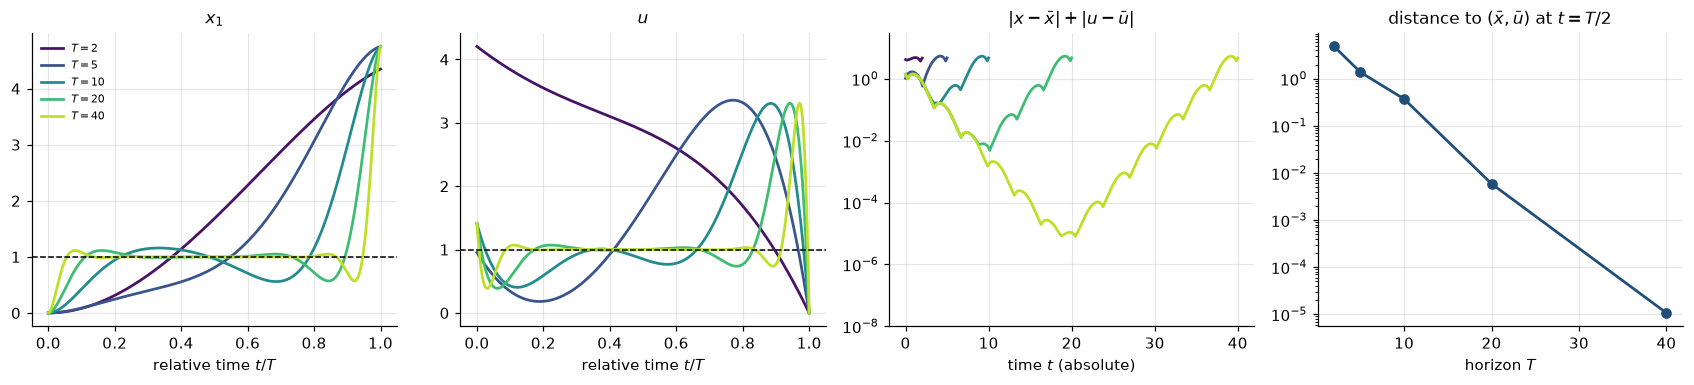

In [2]:
A, B = harmonic_oscillator()                       # E1
C = np.eye(2)
x_star, x0 = np.array([2.0, 7.0]), np.zeros(2)     # target and initial state of p. 250
x_bar, u_bar, p_bar = lq_steady_state(A, B, C, x_star)

horizons = [2.0, 5.0, 10.0, 20.0, 40.0]
solutions = {}
for T in horizons:
    t = np.linspace(0, T, 4001)
    x, p, u = lq_optimality_system(A, B, C, x_star, x0, T, t)
    solutions[T] = (t, x, p, u)
    mid = len(t) // 2
    dev = np.linalg.norm(x[mid] - x_bar) + abs(u[mid, 0] - u_bar[0])
    print(f"T = {T:4.0f}: at t = T/2, x = {x[mid]}, u = {u[mid, 0]: .5f};  distance to the steady optimum {dev:.2e}")

fig, axes = plt.subplots(1, 4, figsize=(15.5, 3.6))
colors = plt.cm.viridis(np.linspace(0.05, 0.9, len(horizons)))
for (T, (t, x, p, u)), color in zip(solutions.items(), colors):
    axes[0].plot(t / T, x[:, 0], color=color, label=f"$T={T:g}$")
    axes[1].plot(t / T, u[:, 0], color=color)
    axes[2].semilogy(t, np.linalg.norm(x - x_bar, axis=1) + np.abs(u[:, 0] - u_bar[0]), color=color)
for ax, value, name in zip(axes[:2], (x_bar[0], u_bar[0]), ("$x_1$", "$u$")):
    ax.axhline(value, color="black", ls="--", lw=1)
    ax.set_xlabel("relative time $t/T$"); ax.set_title(name)
axes[2].set_ylim(1e-8, 30); axes[2].set_xlabel("time $t$ (absolute)"); axes[2].set_title(r"$|x-\bar x|+|u-\bar u|$")
axes[0].legend(fontsize=7)
mids = [np.linalg.norm(solutions[T][1][2000] - x_bar) + abs(solutions[T][3][2000, 0] - u_bar[0]) for T in horizons]
axes[3].semilogy(horizons, mids, "o-", color=COLORS["state"])
axes[3].set_xlabel("horizon $T$"); axes[3].set_title("distance to $(\\bar x,\\bar u)$ at $t=T/2$")
plt.tight_layout(); plt.show()

**Figure 1.** Optimal LQ solutions for E1 with target $x^*=(2,7)$, from $x^0=0$, for $T=2,5,10,20,40$. *First two panels:* $x_1$ and $u$ against the relative time $t/T$, with the steady values $\bar x_1=1$ and $\bar u=1$ of §3 (dashed). *Third panel:* the distance $|x-\bar x|+|u-\bar u|$ against the *absolute* time $t$, on a logarithmic scale. *Right:* the same distance at $t=T/2$, against $T$.

*Interpretation (answer to the prediction).* For long horizons the optimal state spends most of the time near $(1,0)$, which is **neither the target $(2,7)$ nor the initial state**, and the control stays near $1$. In the third panel all curves leave $t=0$ along the same initial layer, and each rises again only in a terminal layer just before its own $T$. **The layers keep a width of order one, independent of $T$, while the plateau between them grows with $T$.** In relative time (first two panels) the layers therefore shrink and the plateau fills the interval. The distance at the midpoint decreases **exponentially in $T$** (right). This is the **turnpike property**.

## 2. The turnpike: three regions
`CORE`

The name comes from economics. The idea goes back to John von Neumann (1945), and the term to Dorfman, Samuelson and Solow (1958), after an American word for a highway (p. 206):

> *"There is a fastest route between any two points; and if the origin and destination are close together and far from the turnpike, the best route may not touch the turnpike. But if the origin and destination are far enough apart, it will always pay to get on to the turnpike and cover distance at the best rate of travel, even if this means adding a little mileage at either end."*

For long horizons the optimal trajectory has three regions: an **initial layer**, where it leaves $x^0$ and joins the turnpike; a long **plateau** near the steady optimum; and a **terminal layer**, where it leaves the plateau because nothing is asked at $t=T$ ($p(T)=0$). The figure below shows them for $T=40$, together with the distance to the steady optimum on a logarithmic scale.

eigenvalues of H: [-0.6761+0.97832j -0.6761-0.97832j  0.6761+0.97832j  0.6761-0.97832j];  gamma = 0.67610;  layer width ln(10^3)/gamma = 10.22


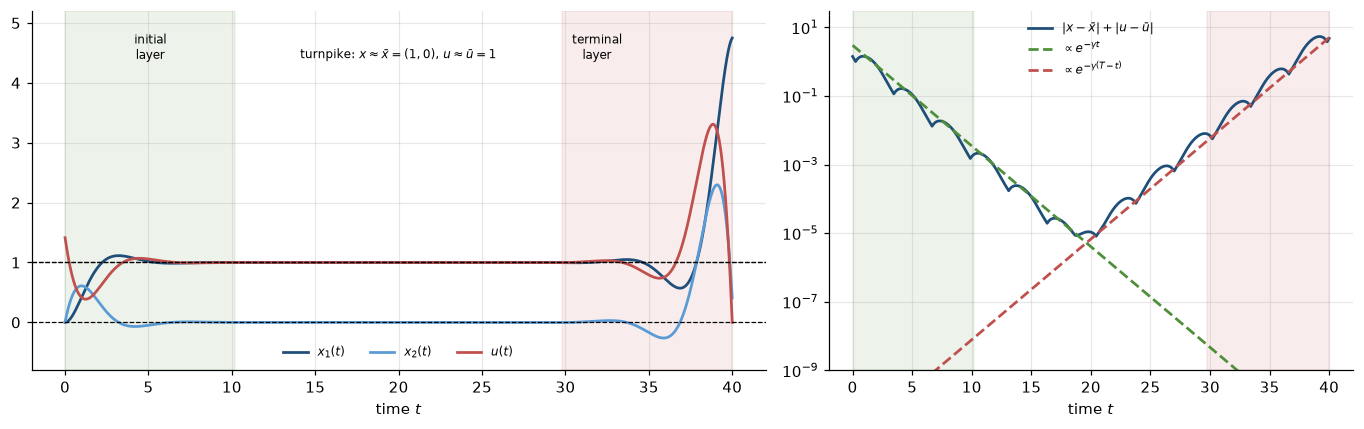

In [3]:
T = 40.0
t, x, p, u = solutions[T]
H = hamiltonian_matrix(A, B, C)
eig_H = np.linalg.eigvals(H)
gamma = np.min(np.abs(eig_H.real))                 # slowest exponential rate of the deviations
dist = np.linalg.norm(x - x_bar, axis=1) + np.abs(u[:, 0] - u_bar[0])
layer = np.log(1e3) / gamma                        # where the distance drops below 1e-3 of its scale
print(f"eigenvalues of H: {np.round(eig_H, 5)};  gamma = {gamma:.5f};  layer width ln(10^3)/gamma = {layer:.2f}")

fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.0), gridspec_kw={"width_ratios": [1.4, 1]})
for ax in axes:
    ax.axvspan(0, layer, color=COLORS["adjoint"], alpha=0.10)
    ax.axvspan(T - layer, T, color=COLORS["control"], alpha=0.10)
axes[0].plot(t, x[:, 0], color=COLORS["state"], label="$x_1(t)$")
axes[0].plot(t, x[:, 1], color=COLORS["state2"], label="$x_2(t)$")
axes[0].plot(t, u[:, 0], color=COLORS["control"], label="$u(t)$")
for value in (x_bar[0], x_bar[1], u_bar[0]):
    axes[0].axhline(value, color="black", ls="--", lw=0.8)
axes[0].text(layer / 2, 4.4, "initial\nlayer", ha="center", fontsize=8)
axes[0].text(T / 2, 4.4, "turnpike: $x\\approx\\bar x=(1,0)$, $u\\approx\\bar u=1$", ha="center", fontsize=8)
axes[0].text(T - layer / 2 - 3, 4.4, "terminal\nlayer", ha="center", fontsize=8)
axes[0].set_ylim(-0.8, 5.2); axes[0].set_xlabel("time $t$"); axes[0].legend(fontsize=8, loc="lower center", ncol=3)
axes[1].semilogy(t, dist, color=COLORS["state"], label=r"$|x-\bar x|+|u-\bar u|$")
axes[1].semilogy(t, 3 * np.exp(-gamma * t), "--", color=COLORS["adjoint"], label=r"$\propto e^{-\gamma t}$")
axes[1].semilogy(t, 5 * np.exp(-gamma * (T - t)), "--", color=COLORS["control"], label=r"$\propto e^{-\gamma (T-t)}$")
axes[1].set_ylim(1e-9, 30); axes[1].set_xlabel("time $t$"); axes[1].legend(fontsize=8, loc="upper center")
plt.tight_layout(); plt.show()

**Figure 2.** The three regions of the optimal solution for $T=40$. *Left:* $x_1$, $x_2$ and $u$, with the steady values (dashed). The shaded bands have width $\ln(10^3)/\gamma\approx10$, where $\gamma\approx0.676$ is the smallest $|\operatorname{Re}\lambda|$ over the eigenvalues of the Hamiltonian matrix of §5. *Right:* the distance to the steady optimum on a logarithmic scale, with the slopes $e^{-\gamma t}$ and $e^{-\gamma(T-t)}$ (dashed).

*Interpretation.* The distance is bounded by a sum of two exponentials, one decaying from $t=0$ and one decaying backward from $t=T$, both at the rate $\gamma$. In the middle it is about $10^{-5}$, a constant times $e^{-\gamma T/2}\approx1.3\cdot10^{-6}$. The oscillations come from the imaginary parts of the eigenvalues, the oscillator's own frequency. The width of the layers does not grow with $T$: a longer horizon only lengthens the plateau. These are the facts the theory must explain.

## 3. The steady problem
`CORE`

The plateau is the solution of the **steady-state control problem**: the same cost, for the steady model (p. 222),
$$
\min_u\ J_{st}(u)=\tfrac12\big(|u|^2+|C(x-x^*)|^2\big)\qquad\text{subject to}\qquad Ax+Bu=0 .
$$
This is a constrained minimization in $\mathbb R^n$, with a unique minimizer $(\bar x,\bar u)$, characterized by
$$
A\bar x+B\bar u=0,\qquad\bar u=-B^*\bar p,\qquad A^*\bar p+C^*C(\bar x-x^*)=0 .
$$
Here $\bar p$ is the Lagrange multiplier of the constraint (notebook 06, §2).

**By hand for the example (p. 250).** $A\bar x+B\bar u=0$ means $\bar x_2=0$ and $\bar x_1=\bar u$. It remains to minimize $(x_1-2)^2+(0-7)^2+x_1^2$ over $x_1$, which gives $x_1=1$:
$$
\bar x=(1,0),\qquad\bar u=1,\qquad J_{st}(\bar u)=\tfrac12(1+1+49)=25.5 .
$$
The steady states of the oscillator all have zero velocity, so the target velocity $7$ is unattainable. The steady optimum balances the position error and the control. The multiplier is $\bar p=(7,-1)$, from $A^*\bar p=x^*-\bar x=(1,7)$.

> **Remark on the source slides.** P. 250 gives $\bar\lambda=(-7,1)$. With the Lagrangian written with the opposite sign of the multiplier, $\bar\lambda=-\bar p$; both describe the same optimum.

In [4]:
print("steady optimum: x_bar =", x_bar, " u_bar =", u_bar, " p_bar =", p_bar)
print("J_st(u_bar) =", 0.5 * (u_bar @ u_bar + (x_bar - x_star) @ (x_bar - x_star)))
for T in horizons:
    t, x, p, u = solutions[T]
    J_T = 0.5 * np.trapezoid(np.sum((x - x_star) ** 2, axis=1) + u[:, 0] ** 2, t)
    print(f"T = {T:4.0f}: J_T / T = {J_T / T:.4f}")

steady optimum: x_bar = [1. 0.]  u_bar = [1.]  p_bar = [ 7. -1.]
J_st(u_bar) = 25.5
T =    2: J_T / T = 17.0291
T =    5: J_T / T = 21.6778
T =   10: J_T / T = 23.6020
T =   20: J_T / T = 24.5519
T =   40: J_T / T = 25.0260


The time-averaged optimal cost $J_T/T$ approaches $J_{st}(\bar u)=25.5$ as $T$ grows. The error decreases like $1/T$, because the two layers contribute a bounded amount. **Averaged in time, the long-horizon problem is the steady problem** (p. 227). The turnpike property is a much stronger, pointwise statement.

## 4. The optimality system
`CORE`

We derive the optimality conditions with a Lagrangian, as in notebook 07. The multiplier $p(t)$ enforces the state equation:
$$
\mathscr L(u,x,p)=\frac12\int_0^T\big(|u|^2+|C(x-x^*)|^2\big)dt+\int_0^T\langle p,\,x'-Ax-Bu\rangle\,dt .
$$
For a variation $\delta x$ with $\delta x(0)=0$, integration by parts gives
$$
\langle p(T),\delta x(T)\rangle-\int_0^T\langle p'+A^*p-C^*C(x-x^*),\,\delta x\rangle\,dt=0 ,
$$
and a variation $\delta u$ gives $\int\langle u-B^*p,\delta u\rangle=0$. Replacing $p$ by $-p$ to match the slides' sign of the control, the **optimality system** (OS) reads (p. 221)
$$
\boxed{\;
\begin{aligned}
&x'=Ax+Bu, && x(0)=x^0,\\
&u=-B^*p,\\
&-p'=A^*p+C^*C(x-x^*), && p(T)=0 .
\end{aligned}\;}
$$
The steady OS of §3 is the same system with all time derivatives set to zero.

**Why an initial condition for $x$ and a terminal one for $p$.** The state is prescribed at $t=0$ by the data, so $\delta x(0)=0$. Nothing is prescribed at $t=T$, so $\delta x(T)$ is arbitrary in the variation above, and its coefficient must vanish: $p(T)=0$. This is a *transversality condition*. A terminal cost $\psi(x(T))$ would give $p(T)=\nabla\psi(x(T))$, as in the state–adjoint–gradient box of notebook 07; a terminal constraint $x(T)=x^1$ would leave $p(T)$ free, as for the minimal-norm controls of notebook 03. The adjoint inherits its endpoint from what the problem leaves free at $t=T$, which is why it runs backward.

> **Remark on the source slides.** Pp. 221–230 use the convention $x_t+Ax=Bu$, so their $A$ is our $-A$. Their OS reads $u=-B^*p$, $-p_t+A^*p=C^*C(x-x^*)$, and their steady system $A\bar x=B\bar u$. All formulas of this notebook are written for $x'=Ax+Bu$; the translation is $A\mapsto-A$.

## 5. Forward–backward structure and hyperbolicity
`CORE`

**Two boundary conditions at two different times.** The state starts at $t=0$ and runs forward; the adjoint is prescribed at $t=T$ and runs backward. Eliminating $u$, the deviations $\xi=x-\bar x$ and $\eta=p-\bar p$ solve the *homogeneous* linear system
$$
\begin{pmatrix}\xi\\ \eta\end{pmatrix}'=\mathcal H\begin{pmatrix}\xi\\ \eta\end{pmatrix},\qquad
\mathcal H=\begin{pmatrix}A&-BB^*\\-C^*C&-A^*\end{pmatrix},\qquad\xi(0)=x^0-\bar x,\quad\eta(T)=-\bar p ,
$$
because the steady optimum absorbs the constant terms. $\mathcal H$ is the **Hamiltonian matrix** of the problem; on p. 230 it is written $\widetilde A$, in the slides' sign convention.

**A scalar toy model** *(pedagogical addition)*. Take $x'=u$ and $J_T=\tfrac12\int_0^T(u^2+(x-x^*)^2)$. The steady optimum is $\bar x=x^*$, $\bar u=0$, $\bar p=0$. The OS gives $\xi'=-\eta$ and $\eta'=-\xi$, hence $\xi''=\xi$ with $\xi(0)=x^0-x^*$ and $\xi'(T)=-\eta(T)=0$. The solution is
$$
\xi(t)=(x^0-x^*)\,\frac{\cosh(T-t)}{\cosh T}=(x^0-x^*)\,\frac{e^{-t}+e^{-(2T-t)}}{1+e^{-2T}} .
$$
For large $T$ it is $(x^0-x^*)e^{-t}$ plus an exponentially small correction: an initial layer of width $O(1)$, and a plateau at $\bar x=x^*$. Here the steady multiplier $\bar p=0$ already satisfies $p(T)=0$, so there is no terminal layer. The term $e^{-(2T-t)}$ is the exponentially small trace of the condition at $t=T$. When $\bar p\ne0$, as in §1, the condition $p(T)=0$ creates a terminal layer of the same width. **The exponents $-1$ and $+1$ of the solutions $e^{-t}$, $e^{t}$ of $\xi''=\xi$ are the eigenvalues $\mp1$ of $\mathcal H=\begin{pmatrix}0&-1\\-1&0\end{pmatrix}$.**

**Hyperbolicity (pp. 230–231).** In general, the turnpike is a direct consequence of the hyperbolicity of the dynamics generated by $\mathcal H$:

- the spectrum of $\mathcal H$ is **symmetric with respect to the imaginary axis**: if $\lambda$ is an eigenvalue, so is $-\lambda$ (Exercise 4);
- under the controllability and observability assumptions of §6, **no eigenvalue lies on the imaginary axis**. Half of them have $\operatorname{Re}\lambda\le-\gamma<0$ and half have $\operatorname{Re}\lambda\ge\gamma>0$.

The solution of the boundary-value problem then splits as $z(t)=z_s(t)+z_u(t)$. The stable part is fixed by the data at $t=0$ and decays like $e^{-\gamma t}$; the unstable part is fixed by the data at $t=T$ and decays backward like $e^{-\gamma(T-t)}$. In the middle both are exponentially small. For the stable part to absorb an *arbitrary* initial state, the stable eigenvectors must project onto the whole state space, i.e. the stable subspace must be a graph over the $x$-variables, and similarly for the unstable subspace and the $p$-variables. Hyperbolicity alone does not guarantee this (Exercise 4); controllability and observability do. The function `lq_optimality_system` of `src/control_utils.py` uses this splitting to solve the OS: it only evaluates decaying exponentials, which removes the growth by $e^{\gamma T}\approx10^{12}$ (for $T=40$) that a naive shooting method would suffer. This removes one source of ill-conditioning, not all: the conditioning of the eigenvector basis and of the small boundary system still matters, and we have not analysed it in general.

> **Predict.** The uncontrollable variant of E2 at $\varepsilon=0$ has a third mode $x_3'=-x_3$ that the control cannot reach. Does the turnpike property hold for it, with $C=I$? And if that mode were neutral, $x_3'=0$?

E1              Kalman rank 2 of 2;  eigenvalues of H: [-0.6761-0.9783j -0.6761+0.9783j  0.6761-0.9783j  0.6761+0.9783j]
E2, eps = 0     Kalman rank 2 of 3;  eigenvalues of H: [-1.    +0.j     -0.6761-0.9783j -0.6761+0.9783j  0.6761-0.9783j
  0.6761+0.9783j  1.    +0.j    ]
E2, neutral x3  Kalman rank 2 of 3;  eigenvalues of H: [-0.6761-0.9783j -0.6761+0.9783j -0.    +0.j      0.    +0.j
  0.6761-0.9783j  0.6761+0.9783j]


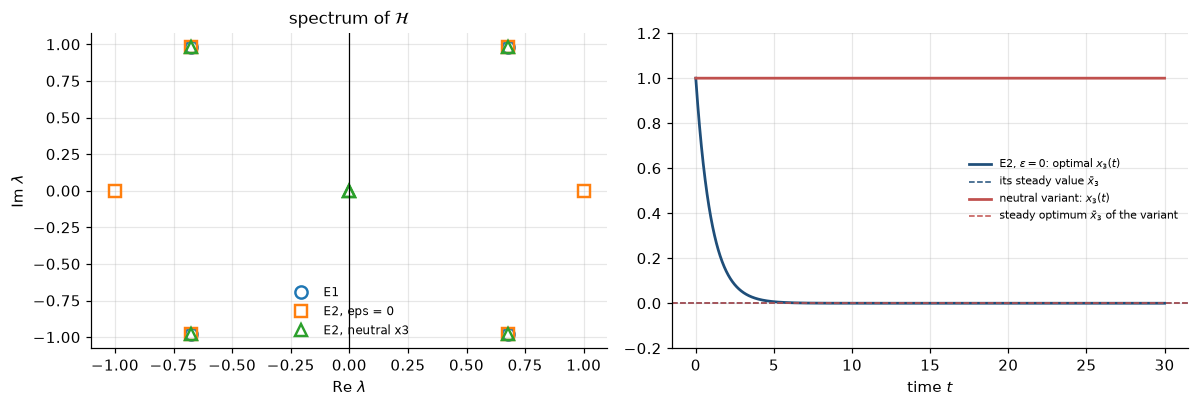

neutral variant: lq_optimality_system refuses it: the Hamiltonian matrix has eigenvalues on the imaginary axis (not hyperbolic)


In [5]:
A2, B2 = near_uncontrollable_system(0.0)           # E2 at eps = 0: x3' = -x3 is not reachable
A2n = A2.copy(); A2n[2, 2] = 0.0                    # variant with a neutral unreachable mode x3' = 0
C3, x_star3, x03 = np.eye(3), np.array([2.0, 7.0, 0.0]), np.array([0.0, 0.0, 1.0])
cases = {"E1": (A, B, C), "E2, eps = 0": (A2, B2, C3), "E2, neutral x3": (A2n, B2, C3)}
for name, (A_, B_, C_) in cases.items():
    ev = np.linalg.eigvals(hamiltonian_matrix(A_, B_, C_))
    print(f"{name:15s} Kalman rank {kalman_rank(A_, B_)} of {A_.shape[0]};  eigenvalues of H: {np.round(np.sort_complex(ev), 4)}")

T3 = 30.0
t3 = np.linspace(0, T3, 3001)
x3, p3, u3 = lq_optimality_system(A2, B2, C3, x_star3, x03, T3, t3)
x3_bar = lq_steady_state(A2, B2, C3, x_star3)[0]
x3n_frozen = np.full_like(t3, x03[2])               # neutral mode: x3' = 0 whatever u is
x3n_bar = lq_steady_state(A2n, B2, C3, x_star3)[0]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 3.8))
for (name, (A_, B_, C_)), marker in zip(cases.items(), ("o", "s", "^")):
    ev = np.linalg.eigvals(hamiltonian_matrix(A_, B_, C_))
    ax1.plot(ev.real, ev.imag, marker, ms=8, fillstyle="none", mew=1.6, label=name)
ax1.axvline(0, color="black", lw=0.8)
ax1.set_xlabel(r"Re $\lambda$"); ax1.set_ylabel(r"Im $\lambda$"); ax1.set_title(r"spectrum of $\mathcal{H}$"); ax1.legend(fontsize=8)
ax2.plot(t3, x3[:, 2], color=COLORS["state"], label=r"E2, $\varepsilon=0$: optimal $x_3(t)$")
ax2.axhline(x3_bar[2], color=COLORS["state"], ls="--", lw=1, label=r"its steady value $\bar x_3$")
ax2.plot(t3, x3n_frozen, color=COLORS["control"], label="neutral variant: $x_3(t)$")
ax2.axhline(x3n_bar[2], color=COLORS["control"], ls="--", lw=1, label=r"steady optimum $\bar x_3$ of the variant")
ax2.set_xlabel("time $t$"); ax2.set_ylim(-0.2, 1.2); ax2.legend(fontsize=7)
plt.tight_layout(); plt.show()
print("neutral variant:", "lq_optimality_system refuses it:", end=" ")
try:
    lq_optimality_system(A2n, B2, C3, x_star3, x03, T3, t3)
except ValueError as err:
    print(err)

**Figure 3.** *Left:* eigenvalues of the Hamiltonian matrix $\mathcal H$ (with $C=I$) for E1, for E2 at $\varepsilon=0$, and for the variant of E2 whose unreachable mode is neutral, $x_3'=0$. *Right:* the third component of the state for $T=30$, from $x^0=(0,0,1)$ with target $x^*=(2,7,0)$: the optimal $x_3$ for E2 at $\varepsilon=0$, and the frozen $x_3$ of the neutral variant, each with its steady optimum (dashed).

*Interpretation (answer to the prediction).* The spectrum of $\mathcal H$ is symmetric with respect to the imaginary axis in all three cases. For E1 there are four eigenvalues $\pm0.676\pm0.978i$. E2 at $\varepsilon=0$ is **not controllable**, yet its unreachable mode is stable, the extra eigenvalues are $\pm1$, $\mathcal H$ is hyperbolic, and for this problem the turnpike holds: $x_3$ decays by itself to its steady value $0$. In the neutral variant $\mathcal H$ has a double eigenvalue $0$. The mode $x_3$ cannot move at all, so it stays at $1$ for all time. The steady problem, which optimizes over all steady states, puts $\bar x_3=0$. **There is no turnpike**, and the solver refuses the problem because $\mathcal H$ is not hyperbolic.

## 6. The turnpike theorem
`CORE`

> **Theorem 1 (exponential turnpike; Porretta–Zuazua 2013; pp. 221–224).**
> *Assumptions:* the pair $(A,B)$ is controllable, $\operatorname{rank}[B,AB,\dots,A^{n-1}B]=n$; and the pair $(A,C)$ is observable, $\operatorname{rank}[C;CA;\dots;CA^{n-1}]=n$. The second condition is void when $C=I$ (p. 223).
> *Conclusion (p. 224):* there are $\gamma>0$ and $K>0$ such that, for $T$ large enough,
> $$\int_{aT}^{bT}\big(|u-\bar u|^2+|x-\bar x|^2\big)\,ds\le K\big(e^{-\gamma aT}+e^{-\gamma(1-b)T}\big)\qquad\text{for every }0\le a\le b\le1 .$$
> *Interpretation:* with $\gamma,K$ independent of $T,a,b$ (implicit on p. 224), on any interval that stays a fixed fraction away from both ends, the optimal pair is exponentially close to the steady optimum.

**Which turnpike?** Three statements of different strength appear in this notebook.

| Statement | Form | Where, and under which assumptions |
|---|---|---|
| averaged | $\frac1T\int_0^T\big(\lvert u-\bar u\rvert^2+\lvert C(x-\bar x)\rvert^2\big)dt\to0$, and $J_T/T\to J_{st}(\bar u)$ | §3 (numerically) and §7, Step 3; needs boundary terms bounded uniformly in $T$ (Step 4) |
| integral, exponential | Theorem 1 | p. 224; controllability of $(A,B)$ and observability of $(A,C)$ |
| pointwise, exponential | $\lvert x(t)-\bar x\rvert+\lvert u(t)-\bar u\rvert\le K\big(e^{-\gamma t}+e^{-\gamma(T-t)}\big)$ for all $t\in[0,T]$ | Figure 2; for LQ problems it follows from the stable/unstable splitting of §5 (we do not compute the constants) |

Each statement implies the one above it, up to the value of the rate. The rate in Theorem 1 is *some* $\gamma>0$. In Figures 1–2, $\gamma$ is the spectral gap $\min\lvert\operatorname{Re}\lambda(\mathcal H)\rvert\approx0.676$, the rate at which the deviations themselves decay; the squared deviations in the theorem's integral then decay at the rate $2\gamma$.

**Two key ingredients (p. 231).**
1. The cost criterion must penalize **both the state and the control**.
2. **Controllability** (together with observability through $C$), which in Theorem 1 is a *sufficient* condition (see the remark below).

Under the theorem's controllability/observability hypotheses, hyperbolicity of $\mathcal H$ follows (§5).

> **Remark on the source slides.** P. 231 states that *"controllability is needed for the turnpike property to hold"*. In the theorem it is a *sufficient* hypothesis. E2 at $\varepsilon=0$ is not controllable, but for this problem the turnpike holds (Figure 3), because its unreachable mode is stable. In LQ theory, the hyperbolicity of $\mathcal H$ together with the graph property of §5 is known to hold under the weaker conditions that the unreachable modes of $(A,B)$ be stable and the unobservable modes of $(A,C)$ be stable. We state this without proof and verify it only on the examples above. The slides' message survives: without some controllability, the turnpike can fail, as the neutral variant shows.

**The first ingredient matters as much.** The minimal-norm control of notebooks 03 and 07 penalizes only the control and imposes a terminal state. Its optimality system has the adjoint isolated, $-\varphi'=A^*\varphi$, with no coupling back from the state ($C=0$). Nothing then ties the trajectory to the steady optimum of a tracking cost. This does not mean that $\mathcal H$ can never be hyperbolic without a state cost: for $A=-1$, $B=1$, $C=0$, $\mathcal H=\begin{pmatrix}-1&-1\\0&1\end{pmatrix}$ has eigenvalues $\pm1$; hyperbolicity then comes from the dynamics $A$ alone. What fails in general is the mechanism of Theorem 1. For the heat equation the minimal-norm controls concentrate near $t=T$ (notebook 07; p. 212: typical control problems for heat and waves *do not seem to exhibit the turnpike property*).

## 7. The proof: dissipativity and the five steps
`DEEPER LOOK`

Write $\xi=x-\bar x$, $\eta=p-\bar p$, so that $u-\bar u=-B^*\eta$ and $\xi'=A\xi-BB^*\eta$, $-\eta'=A^*\eta+C^*C\xi$.

**Step 1: the dissipativity identity (p. 225).**
$$
\frac{d}{dt}\langle\xi,\eta\rangle=\langle A\xi-BB^*\eta,\eta\rangle-\langle\xi,A^*\eta+C^*C\xi\rangle=-|B^*\eta|^2-|C\xi|^2 .
$$
The terms $\langle A\xi,\eta\rangle$ and $\langle\xi,A^*\eta\rangle$ cancel.

> **Remark on the source slides.** P. 225 prints $[(x-\bar x)(p-\bar p)]_t=-|B^*(p-\bar p)|^2+|C(x-\bar x)|^2$. The second sign must be negative, as computed above and as used on p. 226.

**Step 2: decay of the correlation (p. 226).** If $B^*$ and $C$ are coercive, $|B^*\eta|^2+|C\xi|^2\ge\gamma(|\eta|^2+|\xi|^2)\ge2\gamma|\langle\xi,\eta\rangle|$, and the identity gives exponential bounds $-Ke^{-\gamma(T-t)}\le\langle\xi,\eta\rangle(t)\le Ke^{-\gamma t}$, once $\langle\xi,\eta\rangle$ is bounded at $t=0$ and $t=T$. These conditions can be relaxed under controllability and observability (p. 226, following Cardaliaguet–Lasry–Lions–Porretta).

**Step 3: convergence of averages (p. 227).** Integrating Step 1 over $(0,T)$, with $\eta(T)=-\bar p$,
$$
\int_0^T\big(|u-\bar u|^2+|C(x-\bar x)|^2\big)dt=\langle\xi(0),\eta(0)\rangle-\langle\xi(T),\eta(T)\rangle=\langle x^0-\bar x,\,p(0)-\bar p\rangle+\langle x(T)-\bar x,\,\bar p\rangle .
$$
If the right-hand side is bounded independently of $T$ (Step 4), then $\frac1T\int_0^T(\dots)\le C/T\to0$, and the averaged minima converge to the steady minimum. This is the computation printed in §3.

> **Remark on the source slides.** P. 227 writes the last term as $-[(x(T)-\bar x)\bar p]$. With $\eta(T)=p(T)-\bar p=-\bar p$, the boundary term $-\langle\xi(T),\eta(T)\rangle$ equals $+\langle x(T)-\bar x,\bar p\rangle$.

**Step 4: bounds on the extremal values (p. 228).** The observability inequality for $(A^*,B^*)$ bounds $|p(0)-\bar p|$ by the observed quantities $\int|B^*\eta|^2$ and $\int|C\xi|^2$. The observability of $(A,C)$ bounds $|x(T)-\bar x|$ in the same way. Inserted into Step 3, this gives bounds independent of $T$. (The displayed inequalities on p. 228 are typographically garbled; we only describe their content.)

**Step 5: the exponential estimate (p. 229).** Integrating Step 1 over $(aT,bT)$,
$$
\int_{aT}^{bT}\big(|u-\bar u|^2+|C(x-\bar x)|^2\big)dt=\langle\xi,\eta\rangle(aT)-\langle\xi,\eta\rangle(bT),
$$
and Step 2 bounds the right-hand side by $K(e^{-\gamma aT}+e^{-\gamma(1-b)T})$. Observability of $(A,C)$ then turns the bound on $C\xi$ into a bound on $\xi$.

**The numerical check.** The identity of Step 3 is verified below on the solution of §1 for $T=20$.

In [6]:
T = 20.0
t, x, p, u = solutions[T]
lhs = np.trapezoid(np.sum((u - u_bar) ** 2, axis=1) + np.sum((x - x_bar) ** 2, axis=1), t)
rhs = (x0 - x_bar) @ (p[0] - p_bar) + (x[-1] - x_bar) @ p_bar
print(f"int (|u - u_bar|^2 + |x - x_bar|^2) = {lhs:.8f};  boundary terms = {rhs:.8f}  (trapezoidal rule, step {t[1] - t[0]:.3f})")

int (|u - u_bar|^2 + |x - x_bar|^2) = 27.74714212;  boundary terms = 27.74711307  (trapezoidal rule, step 0.005)


## 8. PDEs: balanced controls for the heat equation
`CORE`

In this section $x$ is the spatial variable, $y$ the state and $u$ the control. Notebook 07 computed the minimal-norm null control of the heat equation, which has no turnpike. Consider instead a control that **balances the state and the control** (p. 217):
$$
\min_u\ \frac12\int_0^T\!\!\int_\Omega|y|^2\,dx\,dt+\frac12\int_0^T\!\!\int_\omega|u|^2\,dx\,dt,\qquad y_t-\Delta y=u\,1_\omega .
$$
Its optimality system couples the state and the adjoint in both directions (p. 217): $y_t-\Delta y=-\varphi1_\omega$ and $-\varphi_t-\Delta\varphi=y$. The source term $y$ in the adjoint equation is the novelty.

**A forward–backward parabolic system (p. 218).** For simplicity take $\omega=\Omega$. Then $y_t-\Delta y=-\varphi$ and $\varphi_t+\Delta\varphi=-y$. On the eigenfunction of $-\Delta$ with eigenvalue $\lambda_j$, the two coefficients solve
$$
\begin{pmatrix}y_j\\ \varphi_j\end{pmatrix}'=\begin{pmatrix}-\lambda_j&-1\\-1&\lambda_j\end{pmatrix}\begin{pmatrix}y_j\\ \varphi_j\end{pmatrix},
$$
with characteristic values $\mu_j^\pm=\pm\sqrt{1+\lambda_j^2}$. The system is a superposition of growing and decaying real exponentials, all with rates at least $\sqrt{1+\lambda_1^2}$. This is the hyperbolic structure of §5, mode by mode, and it is compatible with the turnpike behaviour. *"The turnpike behaviour is automatically ensured by the fact that the optimality criterion on the choice of the control is modified to weight both state and control and provided $T\gg1$"* (p. 219).

**Waves (p. 220).** The same holds for the wave equation: the control and the controlled trajectories are close to the steady ones during most of the interval when $T\gg1$ (Gugat–Trélat–Zuazua, 2016). In infinite dimension the controllability ingredient becomes a condition on $\omega$. For the heat equation on a bounded domain, null controllability holds for every nonempty open $\omega\subset\Omega$ (notebook 07, Theorem 2, cited), and p. 234 states the turnpike for the heat equation with any such control support, within the extension of the linear theory to semigroups (Porretta–Zuazua, 2013), which we do not prove. For the wave equation $\omega$ must satisfy the Geometric Control Condition; when it fails, only weaker turnpike properties with slower rates are known (p. 234).

## 9. Nonlinear turnpike and open problems
`RESEARCH WINDOW`

**Nonlinear finite-dimensional systems (pp. 234–238; Trélat–Zuazua, 2015).** The strategy of proof is local (p. 235): write the optimality system, linearize it around the steady optimum, check the hyperbolic structure of the linearized system, and return to the nonlinear problem by perturbation theory. The slides' example (p. 237) is $x_1'=x_2$, $x_2'=1-x_1+x_2^3+u$, with cost $\tfrac12\int((x_1-1)^2+(x_2-1)^2+(u-2)^2)$, whose static optimum is $\bar x=(2,0)$, $\bar u=1$ (Exercise 5).

**Local versus global turnpike (pp. 239–240).** For $x'=-3x+3x^3+u$ with cost $\int((x-1)^2+(u-1)^2)$, the static problem has a global minimizer $\bar x\approx0.78$ ($\bar u\approx0.91$) and a local one $\bar x_{\rm loc}\approx-1.10$ ($\bar u\approx0.73$). Which of the two a long-horizon optimal trajectory approaches depends on the initial data, the accessibility of each optimum, the cost of the transition and the horizon; the local analysis of p. 235 does not decide it (Exercise 6).

**Semilinear heat (pp. 242–246; Porretta–Zuazua).** For $y_t-\Delta y+y^3=u1_\omega$ with a tracking cost, the linearized optimality system around the steady optimum $(\bar y,\bar\varphi)$ reads (p. 245) $z_t-\Delta z+3\bar y^2z=-\psi1_\omega$, $-\psi_t-\Delta\psi+3\bar y^2\psi=\rho z$ with $\rho(x)=1-6\bar y\bar\varphi$. With the adjoint convention of notebook 08 ($u=-\psi1_\omega$), this is the OS of the LQ problem $\min\frac12\int\!\!\int_\Omega\rho\,|z|^2+\frac12\int\!\!\int_\omega|u|^2$: $\rho$ is a weight on the **state**, with unit weight on the control. The turnpike holds as soon as $\rho\ge\delta>0$, a positive state cost as in the first ingredient of §6, which is guaranteed when the target is small enough.

> **Remark on the source slides.** P. 245 writes the LQ functional with $\rho$ multiplying the *control*, $\int\!\!\int_\omega\rho f^2$, which is inconsistent with its own optimality system, where $\rho$ multiplies $z$ in the adjoint equation; the version above is the one consistent with the equations. Similarly, the functional of p. 242 has $\int\!\!\int_\omega f^2$ without the factor $\frac12$, while the optimality system of p. 243 ($f=-\varphi1_\omega$) corresponds to $\frac12\int\!\!\int_\omega f^2$. Whether second-order optimality conditions of the steady problem suffice is under investigation (p. 246).

**Open problems listed in the slides (pp. 247–249).** The turnpike for nonlinear PDEs without smallness conditions; optimal control of time-dependent diffusivity coefficients, $y_t-\operatorname{div}(\sigma(x,t)\nabla y)=0$; combining the local analysis with dissipativity techniques (Grüne et al.); periodic turnpike; turnpike for shape design; and the use of turnpike to solve constrained controllability problems in large time. The literature goes back to discrete-time economic models (McKenzie, 1963) and includes biology, locomotion and model predictive control (p. 236).

## 10. Control ↔ ML: long horizons and deep networks
`CORE` · **FORWARD CONNECTION**

A residual network with $K$ layers can be read as an Euler discretization, with step $h$, of a controlled ODE on $[0,Kh]$ ([notebook 13](13_resnets_neural_odes.ipynb)). Adding layers can mean two different things: refining the step on a *fixed* horizon, which approximates one continuous-time problem better; or keeping $h$ fixed so that the horizon $Kh$ grows, which is a long-horizon problem in the sense of this notebook. Turnpike theory speaks to the second reading. Training such a network with a running cost on the parameters and the features is then a long-horizon optimal control problem. Turnpike theory suggests that such long controlled evolutions may develop an interior regime that is largely independent of the transients at the two ends. This is a hypothesis to be examined, not a theorem about neural networks: the results of this notebook concern linear-quadratic problems with controllability, and deep networks do not generically satisfy a turnpike theorem. The slides cite this line of work as *Turnpike in optimal control of PDEs, ResNets, and beyond* (Geshkovski–Zuazua, *Acta Numerica* 2022; p. 331), and link autonomous, very wide neural fields to turnpike theory (p. 354; [notebook 14](14_classification_as_simultaneous_control.ipynb)).

## 11. Common misconceptions
`CORE`

**"Over a long horizon, the optimal state goes to the target."** It goes to the *steady optimum* $\bar x$, which balances the target against the control, and which may differ from $x^*$ (here $(1,0)$ versus $(2,7)$).

**"The turnpike is a property of the system."** It depends on the cost. The minimal-norm heat controls of notebook 07 show no turnpike; in Theorem 1, costs that penalize state and control do, under its hypotheses.

**"Controllability is necessary for the turnpike."** It is a sufficient hypothesis. In the examples of Figure 3, a stable unreachable mode is harmless (E2 at $\varepsilon=0$) and a neutral one destroys the turnpike.

**"Long horizons make the problem harder to solve."** Naive shooting becomes ill-conditioned like $e^{\gamma T}$; a solver that uses the stable/unstable splitting avoids that exponential growth (other sources of ill-conditioning remain possible). Hyperbolicity is both the explanation and the remedy for this particular difficulty.

**"The layers widen as $T$ grows."** Their width is set by $1/\gamma$, independently of $T$ (Figure 2).

## 12. What you should remember
`CORE`

1. LQ problem: $\min\tfrac12\int_0^T(|u|^2+|C(x-x^*)|^2)$ subject to $x'=Ax+Bu$. Steady problem: the same cost subject to $Ax+Bu=0$.
2. Optimality system: $u=-B^*p$, $-p'=A^*p+C^*C(x-x^*)$, $p(T)=0$. It is a forward–backward system.
3. The deviations from the steady optimum solve $z'=\mathcal Hz$ with the Hamiltonian matrix $\mathcal H=\begin{pmatrix}A&-BB^*\\-C^*C&-A^*\end{pmatrix}$, whose spectrum is symmetric about the imaginary axis.
4. Hyperbolicity of $\mathcal H$, with the graph property of §5, gives an initial layer $\sim e^{-\gamma t}$, a plateau and a terminal layer $\sim e^{-\gamma(T-t)}$: the turnpike.
5. Theorem: controllability of $(A,B)$ and observability of $(A,C)$ give the exponential turnpike. Its proof rests on the dissipativity identity $\frac{d}{dt}\langle\xi,\eta\rangle=-|B^*\eta|^2-|C\xi|^2$.
6. Two ingredients: a cost on state and control, and controllability (sufficient, not necessary). Minimal-norm heat controls lack the first; a neutral unreachable mode violates the second.
7. Balanced heat controls have characteristic values $\pm\sqrt{1+\lambda_j^2}$ and a turnpike.

## 13. Exercises

★ conceptual · ★★ mathematical · ★★★ computational. `FIRST PASS` exercises are the minimum route; `STANDARD` ones consolidate the notebook; `ADVANCED` ones are optional. Reference solutions are kept in a separate instructor notebook. Try first.

**Exercise 1 ★ (predict the plateau)** · `FIRST PASS`. For the example of §1 with the new target $x^*=(3,-5)$, predict the turnpike $(\bar x,\bar u)$ *before* computing, and then check it with `lq_steady_state`. Why does the target velocity not matter?

**Exercise 2 ★★ (steady optimum by hand)** · `FIRST PASS`. For E1 with $C=I$ and a general target $x^*=(a,b)$, compute $\bar x$, $\bar u$ and $\bar p$ from the steady optimality system $A\bar x+B\bar u=0$, $\bar u=-B^*\bar p$, $A^*\bar p+\bar x-x^*=0$. Check that you recover p. 250 for $(a,b)=(2,7)$.

**Exercise 3 ★★ (the dissipativity identity)** · `STANDARD`. (a) Derive $\frac{d}{dt}\langle x-\bar x,p-\bar p\rangle=-|B^*(p-\bar p)|^2-|C(x-\bar x)|^2$ from the time-dependent and steady optimality systems. (b) Integrate it to get the identity of Step 3 (§7), and use it to show $J_T(u)/T\to J_{st}(\bar u)$ *provided* the boundary terms stay bounded. *Hint:* write $J_T$ in terms of $u-\bar u$ and $x-\bar x$, and use the steady optimality conditions to write the cross terms as an exact derivative.

**Exercise 4 ★★ (spectral symmetry)** · `STANDARD`. Let $J=\begin{pmatrix}0&I\\-I&0\end{pmatrix}$. (a) Show that $J\mathcal H$ is symmetric. (b) Deduce that $\mathcal H^\top=J\mathcal HJ$ and that $\mathcal H$ and $-\mathcal H$ have the same eigenvalues. Since $\mathcal H$ is real, conclude that its spectrum is symmetric with respect to both axes. (c) For the scalar model $A=a$, $B=b$, $C=c$, compute the eigenvalues $\pm\sqrt{a^2+b^2c^2}$, and say when they are on the imaginary axis.

**Exercise 5 ★★★ (a nonlinear turnpike, p. 237)** · `ADVANCED`. For $x_1'=x_2$, $x_2'=1-x_1+x_2^3+u$, $x(0)=(1,1)$, and $\min\tfrac12\int_0^T((x_1-1)^2+(x_2-1)^2+(u-2)^2)$: (a) verify the static optimum $\bar x=(2,0)$, $\bar u=1$. (b) Write the optimality system. (c) For $T=5,10,20$, compute with `scipy.integrate.solve_bvp` solutions of the optimality system, that is, *stationary candidates*; report the solver status and the largest residual, and observe whether the candidates approach the static optimum in the middle of the interval. (d) Why does a converged `solve_bvp` run not certify that a candidate is a global minimizer of the cost?

In [7]:
# TODO: student exercise (Exercise 5)
# Write the right-hand side of the nonlinear optimality system z = (x1, x2, p1, p2) and its boundary
# conditions x(0) = (1, 1), p(T) = 0, and solve with scipy.integrate.solve_bvp for T = 5, 10, 20.

def nonlinear_os(t, z):
    ...  # your code here
    return None

**Exercise 6 ★★★ (local versus global, p. 240)** · `ADVANCED`. For $x'=-3x+3x^3+u$ and the cost $\int_0^T((x-1)^2+(u-1)^2)$: (a) reduce the static problem to the minimization of $g(x)=(x-1)^2+(3x-3x^3-1)^2$ and find its two local minimizers, comparing with the slide's values $\bar x\approx0.78$, $\bar u\approx0.91$ and $\bar x_{\rm loc}\approx-1.10$, $\bar u\approx0.73$. (b) Which one is the global minimizer of the static problem? (c) *Discussion:* for a long horizon and a start near $-1.1$, which factors decide whether the optimal trajectory stays near the local steady optimum or moves to the global one? Discuss the accessibility of the global optimum under the drift, the cost of the transition, the length of the horizon, and the fact that the turnpike analysis of p. 235 is local. Can the question be settled without solving the time-dependent problem?

## Where are we going?
`CORE`

This closes Part II. Its tools are minimization, gradient flows and their discretization (06), adjoints and duality for PDEs (07), and the long-horizon structure of optimal control (08). Part III turns to **learning from data**, where the same machinery returns under new names: the cost becomes a loss, the control becomes the parameters of a model, and gradient descent becomes training. In Part IV, deep residual networks are read as controlled dynamical systems over long horizons, and the turnpike of this notebook becomes a question about deep architectures (notebooks [13](13_resnets_neural_odes.ipynb) and [14](14_classification_as_simultaneous_control.ipynb)).

## Source map
`CORE`

All page numbers are PDF pages of `CML_slides_20250520.pdf`; the machine-readable version is `source_map.csv`.

| Section | PDF pages | Content in the slides |
|---|---|---|
| Where are we? | 201–205 | Long horizons; steady design; $T\to\infty$ + control vs control + $T\to\infty$ |
| §1 Example | 250, 221 | E1 with target $(2,7)$; the LQ problem |
| §2 Turnpike | 206–208 | Origins of the term; turnpike theory |
| §3 Steady problem | 222, 250 | Steady OS; $\bar x=(1,0)$, $\bar u=1$ |
| §4 Optimality system | 221 | $u=-B^*p$, adjoint with $C^*C(x-x^*)$, $p(T)=0$ |
| §5 Hyperbolicity | 230–231 | $\widetilde A$; symmetric spectrum; stability + instability |
| §6 Theorem | 223–224, 231 | Kalman and observability conditions; exponential estimate; two ingredients |
| §7 Proof | 225–229 | Dissipativity identity; Steps 2–5 |
| §8 PDE | 212, 217–220, 234 | Balanced heat controls; $\pm\sqrt{1+\lambda_j^2}$; waves; GCC |
| §9 Research window | 234–249 | Nonlinear, local vs global, semilinear heat, open problems, literature |
| §10 Control ↔ ML | 331, 354 | Turnpike in ResNets; wide autonomous fields |

The source-map rows also record the pedagogical additions (the computations and Figures 1–3, the averaged-cost check, the scalar toy model, the E2 analysis and the neutral variant, the dichotomy solver) and the remarks on the source slides (sign convention pp. 221–230; $\bar\lambda=-\bar p$ on p. 250; signs on pp. 225 and 227; p. 231 controllability as a sufficient condition).